# Cách Dự báo Time-Series sử dụng Autoregression



## Giới thiệu



Forecasting (Dự báo) là một lĩnh vực rộng lớn với nhiều model (mô hình) khác nhau để mô phỏng time series của bạn. Trong các bài viết trước, chúng ta đã đề cập đến một số mô hình dự báo cơ bản và khám phá họ các mô hình exponential smoothing phổ biến.

Trong bài viết này, chúng ta sẽ bắt đầu hành trình của mình vào một họ mô hình dự báo khác bắt đầu với autoregression. Chúng ta sẽ xem xét lý thuyết và kiến thức nền tảng cần thiết để dự báo với mô hình này và sau đó đi sâu vào hướng dẫn với Python.


## Autoregression là gì?




### Tổng quan


Autoregression là khi bạn dự báo một time series sử dụng một tổ hợp tuyến tính có trọng số của các giá trị trước đó (lags - độ trễ) của time series đó. Vì chúng ta đang hồi quy một giá trị mục tiêu đối với chính nó, nó được gọi là auto-regression (tự hồi quy).

Về mặt toán học, chúng ta có thể viết autoregression như sau:


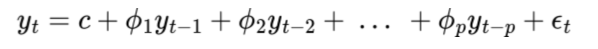
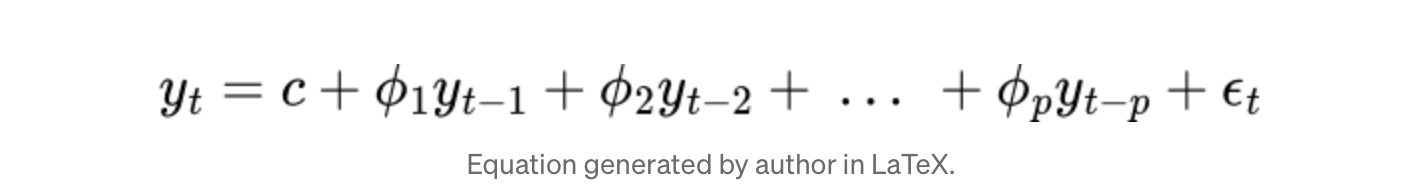

Trong đó y là time series chúng ta đang dự báo tại các bước thời gian khác nhau, ϕ là các coefficients (hệ số) được fit cho các lags của time series, ε là error term (sai số) (thường được phân phối chuẩn) và p là số lượng các thành phần lagged được đưa vào mô hình, điều này còn được gọi là order (bậc).

Một vài mô hình nổi tiếng xuất hiện từ phương trình autoregression này:
- Nếu chúng ta không có coefficients hoặc tất cả đều bằng không, thì đây chỉ là white noise
- Nếu chúng ta chỉ có ϕ_1 = 1 và các coefficients khác bằng không, thì đây là random walk.


### Yêu cầu


Để xây dựng một mô hình autoregressive, được khuyến nghị có một time series stationary (dừng). Stationarity (Tính dừng) có nghĩa là time series không biểu hiện bất kỳ trend (xu hướng) dài hạn hoặc seasonality (tính mùa vụ) rõ ràng nào. Lý do chúng ta cần stationarity là để đảm bảo các thuộc tính thống kê của time series nhất quán theo thời gian, khiến nó dễ mô hình hóa hơn (sẽ được giải thích chi tiết hơn sau).

Stationarity có thể đạt được bằng cách ổn định trend thông qua differencing (lấy sự khác biệt) và ổn định variance (phương sai) thông qua biến đổi Logarithm hoặc Box-Cox.


### Ước lượng


Nhu cầu về stationarity trở nên rõ ràng hơn khi chúng ta đang training (huấn luyện) mô hình. Dữ liệu stationary có các thuộc tính thống kê không đổi như mean (trung bình) và variance (phương sai). Do đó, tất cả các điểm dữ liệu thuộc về cùng một phân phối xác suất thống kê mà chúng ta có thể dựa vào để xây dựng mô hình. Hơn nữa, các forecasts (dự báo) được coi là các biến ngẫu nhiên và sẽ thuộc về cùng một phân phối với dữ liệu training (lags). Về cơ bản nó đảm bảo dữ liệu trong tương lai sẽ giống với quá khứ.

Vì dữ liệu stationary thuộc về một phân phối nào đó (thường là phân phối chuẩn), chúng ta thường ước lượng các coefficients và parameters (tham số) của mô hình autoregressive bằng Maximum Likelihood Estimation (MLE - Ước lượng hợp lý cực đại). MLE suy ra các giá trị tối ưu của các parameters và coefficients tạo ra xác suất cao nhất để có được dữ liệu time series của chúng ta. MLE cho dữ liệu phân phối chuẩn, cho kết quả tương tự như thực hiện ordinary least squares (bình phương tối thiểu thông thường). Do đó, least squares cũng thường được sử dụng.


### Lựa chọn Order (Bậc)


Trước khi fitting (khớp) và ước lượng mô hình, chúng ta cần biết bao nhiêu lags (order - bậc), p, cần đưa vào. Một cách để làm điều này là thông qua vẽ partial autocorrelation function (PACF - hàm tự tương quan riêng phần) của time series. Điều này đo lường mức độ các lags nhất định tương quan trực tiếp với nhau. Do đó, chúng ta có thể suy ra lags nào có ý nghĩa thống kê nhất và loại bỏ những lags không có khi xây dựng mô hình của chúng ta. Chúng ta sẽ xem xét cách thực hiện quy trình này trong hướng dẫn Python sau trong bài viết.

Tuy nhiên, một kỹ thuật kỹ lưỡng hơn là chỉ đơn giản là lặp qua tất cả các tổ hợp có thể có của các thành phần lag và chọn mô hình có điểm số tốt nhất trên AIC. Điều này tương tự như hyperparameter tuning thông thường và chắc chắn là phương pháp mạnh mẽ hơn, nhưng tất nhiên phụ thuộc vào các ràng buộc về mặt tính toán.


## Hướng dẫn Python




### Dữ liệu


In [3]:
# Import các package
import plotly.express as px
import pandas as pd

# Đọc dữ liệu
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])


def plot_passenger_volumes(df: pd.DataFrame,
                           y: str) -> None:
    """Hàm chung để vẽ dữ liệu hành khách."""

    fig = px.line(df, x='Month', y=y, labels={'Month': 'Date'})
    fig.update_layout(template="simple_white", font=dict(size=18), title_text='Hành khách Hàng không',
                      width=650, title_x=0.5, height=400)

    return fig.show()


# Vẽ biểu đồ dữ liệu hành khách hàng không
plot_passenger_volumes(df=data, y='#Passengers')


Time series có một trend (xu hướng) rõ ràng và seasonality (tính mùa vụ) hàng năm rõ ràng đang tăng theo thời gian. Do đó, chúng ta cần làm cho nó stationary (dừng) bằng cách thực hiện differencing và áp dụng biến đổi Box-Cox:


In [4]:
# Import các package
from scipy.stats import boxcox

# Làm cho target stationary
data['Passengers_boxcox'], lam = boxcox(data['#Passengers'])
data["Passenger_stationary"] = data["Passengers_boxcox"].diff()
data.dropna(inplace=True)

# Vẽ biểu đồ dữ liệu hành khách hàng không stationary
plot_passenger_volumes(df=data, y='Passenger_stationary')


### Mô hình hóa (modeling)


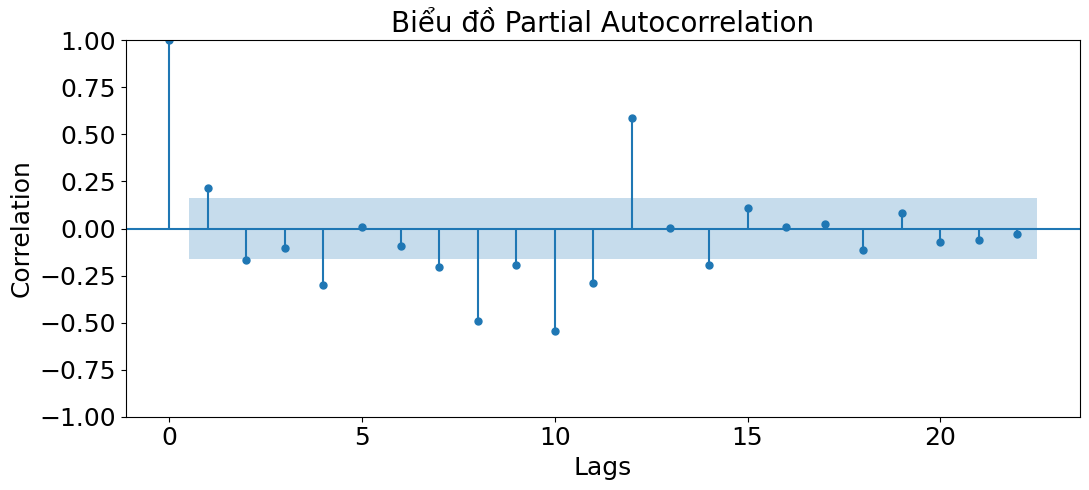

In [5]:
# Import các package
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# Vẽ partial autocorrelation
plt.rc("figure", figsize=(11,5))
plot_pacf(data['Passenger_stationary'], method='ywm')
plt.xlabel('Lags', fontsize=18)
plt.ylabel('Correlation', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title('Biểu đồ Partial Autocorrelation', fontsize=20)
plt.tight_layout()
plt.show()


Các lags ngoài vùng màu xanh được xem là có ý nghĩa thống kê đáng kể và nên được đưa vào làm features (đặc trưng) cho mô hình autoregressive của chúng ta. Từ biểu đồ trên, có vẻ như các lags 1, 2, 4, 7, 8, 9, 10, 11, 12 và 13 là có ý nghĩa. Lưu ý cách lag 12 có peak (đỉnh) lớn nhất. Điều này là do time series của chúng ta được đánh chỉ số theo tháng và có seasonality hàng năm, do đó lag 12 chính xác là sự chênh lệch một năm.

Tuy nhiên, để xây dựng mô hình của chúng ta, chúng ta sẽ sử dụng phương pháp được khuyến nghị là chỉ đơn giản lặp qua tất cả các tổ hợp có thể có của các lags và chọn mô hình tốt nhất từ phân tích đó. Vì dataset của chúng ta khá nhỏ, điều này dễ dàng khả thi về mặt tính toán.


Ở đây chúng ta sử dụng ar_select_order từ statsmodels để xác định số lượng lags tối ưu cần đưa vào mô hình autoregressive. Trong trường hợp này, chúng ta đã đặt mô hình của mình thử các tổ hợp lên đến lag 15. Sau đó, mô hình được fit với kết quả từ ar_select_order bằng cách sử dụng class AutoReg từ statsmodels.


In [22]:
# Import các package
from statsmodels.tsa.ar_model import AutoReg, ar_select_order

# Chia train và test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]

# Xây dựng mô hình AR
selector = ar_select_order(train['Passenger_stationary'], 15)
model = AutoReg(train['Passenger_stationary'], lags=selector.ar_lags).fit()


c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.

c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.



In [23]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             AutoReg Model Results                              
================================================================================
Dep. Variable:     Passenger_stationary   No. Observations:                  115
Model:                      AutoReg(13)   Log Likelihood                 106.029
Method:                 Conditional MLE   S.D. of innovations              0.086
Date:                  Sun, 08 Feb 2026   AIC                           -182.058
Time:                          23:33:42   BIC                           -142.684
Sample:                              13   HQIC                          -166.114
                                    115                                         
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.0583      0.021      2.759      0.006       0.017       0.100
Passenger_stationary.L1     -0.3713      0.095     -3.892      0.000      -0.558      -0.184
Passenger_stationary.L2     -0.2441      0.078     -3.123      0.002      -0.397      -0.091
Passenger_stationary.L3     -0.1511      0.081     -1.867      0.062      -0.310       0.008
Passenger_stationary.L4     -0.2624      0.078     -3.359      0.001      -0.416      -0.109
Passenger_stationary.L5     -0.1219      0.081     -1.501      0.133      -0.281       0.037
Passenger_stationary.L6     -0.2167      0.077     -2.826      0.005      -0.367      -0.066
Passenger_stationary.L7     -0.1880      0.078     -2.406      0.016      -0.341      -0.035
Passenger_stationary.L8     -0.2924      0.079     -3.725      0.000      -0.446      -0.139
Passenger_stationary.L9     -0.1567      0.083     -1.896      0.058      -0.319       0.005
Passenger_stationary.L10    -0.2572      0.080     -3.202      0.001      -0.415      -0.100
Passenger_stationary.L11    -0.1248      0.083     -1.499      0.134      -0.288       0.038
Passenger_stationary.L12     0.6726      0.082      8.234      0.000       0.512       0.833
Passenger_stationary.L13     0.2675      0.097      2.756      0.006       0.077       0.458
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1             0.8675           -0.4940j            0.9983           -0.0824
AR.2             0.8675           +0.4940j            0.9983            0.0824
AR.3             1.1989           -0.0000j            1.1989           -0.0000
AR.4             0.4958           -0.8682j            0.9998           -0.1674
AR.5             0.4958           +0.8682j            0.9998            0.1674
AR.6             0.0127           -1.0116j            1.0117           -0.2480
AR.7             0.0127           +1.0116j            1.0117            0.2480
AR.8            -0.5040           -0.8714j            1.0067           -0.3334
AR.9            -0.5040           +0.8714j            1.0067            0.3334
AR.10           -0.8829           -0.5138j            1.0215           -0.4161
AR.11           -0.8829           +0.5138j            1.0215            0.4161
AR.12           -1.1284           -0.0000j            1.1284           -0.5000
AR.13           -2.5628           -0.0000j            2.5628           -0.5000
------------------------------------------------------------------------------
"""

### Kết quả


Các forecasts (dự báo) được tạo ra từ mô hình đã fit này là cho time series đã được differenced và biến đổi Box-Cox mà chúng ta đã tạo ra trước đó. Do đó, chúng ta phải un-difference (đảo ngược differencing) và áp dụng biến đổi Box-Cox nghịch đảo cho các predictions (dự đoán) để có được khối lượng hành khách hàng không được dự báo thực tế:


In [ ]:
# Import các package
from scipy.special import inv_boxcox
import plotly.graph_objects as go

# Lấy forecasts và chuyển đổi sang khối lượng hành khách thực tế
transformed_forecasts = list(model.forecast(steps=len(test)))
boxcox_forecasts = []
for idx in range(len(test)):
    # Đảo ngược difference
    if idx == 0:
        boxcox_forecast = transformed_forecasts[idx] + train['Passengers_boxcox'].iloc[-1]
    else:
        boxcox_forecast = transformed_forecasts[idx] + boxcox_forecasts[idx-1]
    # Lưu forecast đã đảo ngược difference
    boxcox_forecasts.append(boxcox_forecast)
# Đảo ngược Box-Cox transformation
forecasts = inv_boxcox(boxcox_forecasts, lam)


def plot_forecasts(forecasts: list[float],
                   title: str) -> None:
    """Hàm để vẽ các forecasts."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['Month'], y=train['#Passengers'], name='Train'))
    fig.add_trace(go.Scatter(x=test['Month'], y=test['#Passengers'], name='Test'))
    fig.add_trace(go.Scatter(x=test['Month'], y=forecasts, name='Forecast'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Ngày',
                      yaxis_title='Khối lượng Hành khách')

    return fig.show()


# Vẽ biểu đồ các forecasts
plot_forecasts(forecasts, 'Autoregression')


c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

c:\Users\DUYEN\anaconda3\envs\jepx\lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



Các forecasts của mô hình autoregressive đã nắm bắt đầy đủ trend (xu hướng) và seasonality (tính mùa vụ) trong time series. Tuy nhiên, seasonality được nắm bắt là kết quả của mô hình có order (bậc) là 13. Điều này có nghĩa là nó bao gồm tất cả các lags trong năm qua (một cho mỗi tháng) để dự báo, dẫn đến việc nó dễ dàng phát hiện seasonality do tính đều đặn của nó.
